# Distribution of Birth Years Over Time 

This notebook provides an analysis of the distribution of birth years over time for the selected population and identifies different generations.

It also highlights changes in gender distribution over time.

Regarding the **Pandas library**, take ten minutes to discover this library with this warm up **tutorial [10 minutes to pandas](https://pandas.pydata.org/docs/user_guide/10min.html)**


In [6]:
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go

In [7]:
import warnings
warnings.filterwarnings('ignore')


## Import the data

The data is available in the da1_data directory and was prepared using the query [documented on this page](../../documentation/wikidata/data-analysis/da1-distribution-of-births-in-time.md)

In [8]:
## create variable declaring the path to the data
path_to_data = 'da1_data/birth-dates-gender.csv'

In [9]:
## creating a Pandas Dataframe (data container in form of a table) 
df_p = pd.read_csv(path_to_data, sep=",", encoding="utf-8", header=0)

## first rows of the dataframe
df_p.head()

,s,label,birthDate,genLabel
0,<http://www.wikidata.org/entity/Q12765268>,Elemír Csere,1917,male
1,<http://www.wikidata.org/entity/Q97193482>,Свистунов Володимир Михайлович,1941,male
2,<http://www.wikidata.org/entity/Q47453056>,Анатолий Брониславович Ринкевич,1950,male
3,<http://www.wikidata.org/entity/Q4511380>,Anita Goel,1973,female
4,<http://www.wikidata.org/entity/Q112432057>,Pavel Pešat,1963,male


In [10]:
## Basic infor about the DataFrame
df_p.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32693 entries, 0 to 32692
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   s          32693 non-null  object
 1   label      32693 non-null  object
 2   birthDate  32693 non-null  int64 
 3   genLabel   32693 non-null  object
dtypes: int64(1), object(3)
memory usage: 1021.8+ KB


In [11]:
### Rename a column
df_p = df_p.rename(columns={'birthDate': 'birthYear'})

In [12]:
### Select the first values of this column
df_p.birthYear.head()

0    1917
1    1941
2    1950
3    1973
4    1963
Name: birthYear, dtype: int64

### Add a column to the DataFrame containing the gender code

In [13]:
### First, we create a function that performs the intended task

## The argument of the ‘code_gender’ function is a name of your choice
# It is then referenced within the function as a variable
# and holds the value entered when the function is called

def code_gender(genLabel):
    if genLabel == 'male':
        # genre masculin
        a = 'M'
    elif genLabel =='female':
        # genre féminin
        a = 'F'
    else:
        # genre autre
        a = 'A'
    return a    

In [14]:
### We test if the function works
print(code_gender('female'))

F


In [15]:
### Add a new column and enter the result of the function in each row
df_p['genCode'] = df_p.apply(lambda x: code_gender(x['genLabel']), axis=1)

In [16]:
### We examine the first five rows that have the value ‘A’ = other
df_p[df_p['genCode']=='A'][:5]

,s,label,birthYear,genLabel,genCode
1508,<http://www.wikidata.org/entity/Q60578554>,Jan Eldridge,1901,non-binary,A
2237,<http://www.wikidata.org/entity/Q93264486>,Ishwar Aggarwal,1945,undisclosed gender,A
4174,<http://www.wikidata.org/entity/Q15990211>,Rachael Padman,1954,trans woman,A
4453,<http://www.wikidata.org/entity/Q4886322>,Rebecca Oppenheimer,1972,trans woman,A
9111,<http://www.wikidata.org/entity/Q23656158>,Lucianne M. Walkowicz,1979,non-binary,A


In [17]:
### Group by gender and count  
df_p.groupby("genCode").size()   # .reset_index(name="count")

genCode
A       12
F     2684
M    29997
dtype: int64

## Effectifs par année

In [18]:
### We inspect the values in the ‘birthYear’ column 
# and check what the data type is
df_p['birthYear'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 32693 entries, 0 to 32692
Series name: birthYear
Non-Null Count  Dtype
--------------  -----
32693 non-null  int64
dtypes: int64(1)
memory usage: 255.5 KB


In [19]:
### If it's an integer (int64) there's nothig to do 
# Otherwise, we change the data type of the BirthYear column
# from 'object' (text) to 'integer'
df_p['birthYear'] = df_p['birthYear'].astype(int)

In [20]:
### On regroupe les données par année et on compte le nombre de naissances par année
# On créé un nouveau DataFrame comme résultat
years_count = pd.DataFrame(df_p.groupby('birthYear').size()).reset_index()
years_count.columns=['year','number']
years_count

,year,number
0,1781,14
1,1782,10
2,1783,20
3,1784,15
4,1785,18
...,...,...
195,1976,179
196,1977,197
197,1978,149
198,1979,163


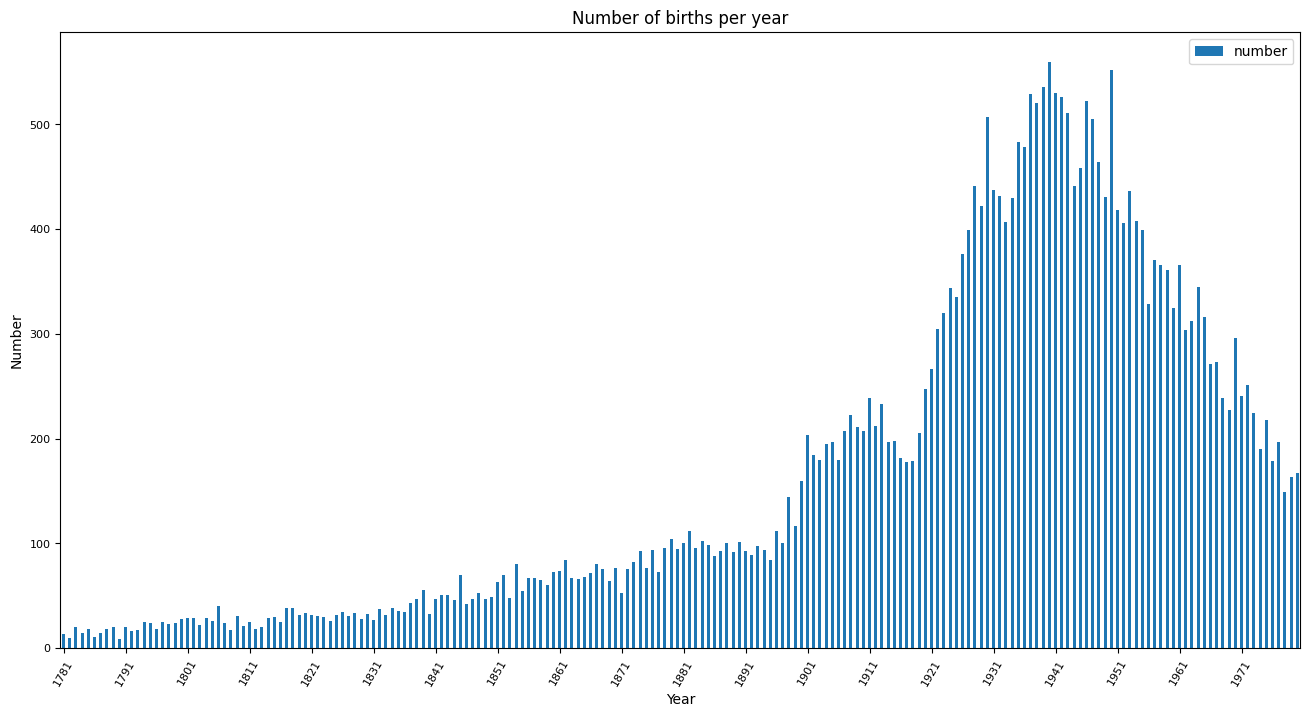

In [21]:
### Représentation graphique des effectifs par année

ax = years_count.plot(x='year', y='number', kind='bar',rot=60, fontsize=8, figsize=(16,8))


max_xticks = 20
xloc = plt.MaxNLocator(max_xticks)
ax.xaxis.set_major_locator(xloc)

plt.ylabel('Number')
plt.xlabel('Year')
plt.title('Number of births per year')
plt.show()

### Issue if years are missing

We delete some years here, although available in reality, in order to illustrate the bias and the solution

In [22]:
## Apparently all years are available with some number of persons born
# But what would happen if a year is missing
missing_years = pd.Index(range(years_count['year'].min(), years_count['year'].max() + 1)).difference(years_count['year']).tolist()
print(missing_years)  # Output: [1902, 1904]

[]


In [23]:
### We randomly delete some years as if there were no births that year
years_count = years_count[~years_count['number'].isin([10,20,30, 40, 50])]

If you create again the plot above, no year appears to be missing

In [24]:
df_y = pd.DataFrame({'year':range(years_count['year'].min(), years_count['year'].max() + 1)})
df_y.head()

,year
0,1781
1,1782
2,1783
3,1784
4,1785


In [25]:
merged = df_y.merge(years_count, on='year', how='left')

In [26]:
merged.head(10)

,year,number
0,1781,14.0
1,1782,NaN
2,1783,NaN
3,1784,15.0
4,1785,18.0
5,1786,11.0
6,1787,15.0
7,1788,18.0
8,1789,NaN
9,1790,9.0


In [27]:
merged['number'] = merged[['number']].fillna(0)

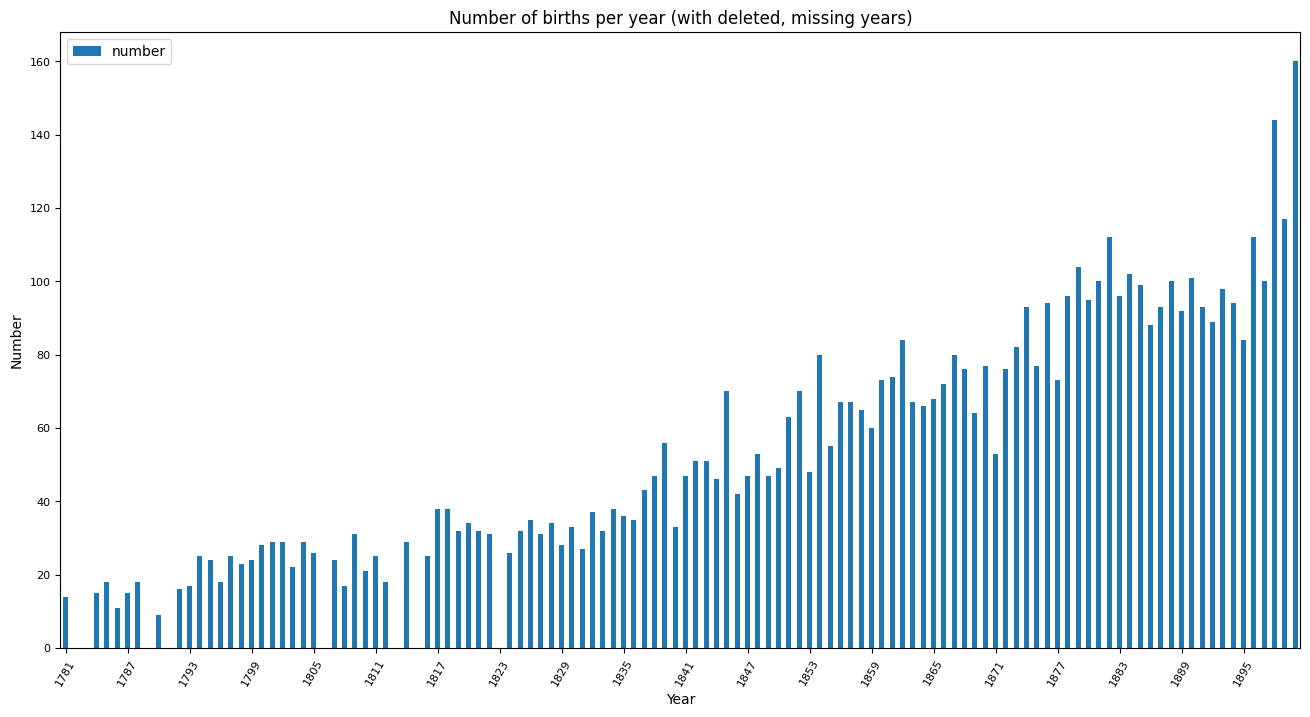

In [30]:
### Représentation graphique des effectifs par année

ax = merged[merged.year < 1901].plot(x='year', y='number', kind='bar',rot=60, fontsize=8, figsize=(16,8))


max_xticks = 20
xloc = plt.MaxNLocator(max_xticks)
ax.xaxis.set_major_locator(xloc)

plt.ylabel('Number')
plt.xlabel('Year')
plt.title('Number of births per year (with deleted, missing years)')
plt.show()

## Group births by 20-year periods

In [31]:
### Créer une copie indépendante du DataFrame (attention aux copies de variables qui sont seulement des alias) 
cdf_p = df_p.copy(deep=True)

In [32]:
cdf_p.head(3)

,s,label,birthYear,genLabel,genCode
0,<http://www.wikidata.org/entity/Q12765268>,Elemír Csere,1917,male,M
1,<http://www.wikidata.org/entity/Q97193482>,Свистунов Володимир Михайлович,1941,male,M
2,<http://www.wikidata.org/entity/Q47453056>,Анатолий Брониславович Ринкевич,1950,male,M


In [33]:
### Année minimale et maximale dans la population
print(min(cdf_p['birthYear']), max(cdf_p['birthYear']))

1781 1980


### Codage par période de vingt ans

In [34]:
### Créer une liste d'années pour séparer en périodes de 25 ans
# noter que la dernière année sera exclue, 
# elle donc doit être supérieure à la valeur maximale 
l_20 = list(range(1781, 2001, 20))
print(l_20[:5],l_20[-5:])

[1781, 1801, 1821, 1841, 1861] [1901, 1921, 1941, 1961, 1981]


In [35]:
### fonction pd.cut : https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.cut.html
# On ajoute une nouvelle colonne qui contient la période sur la base de la liste précédente
# et de la valeur de l'année

cdf_p['periodes'] = pd.cut(cdf_p['birthYear'], l_20, right=False)

### Transformer le code ajouté pour qu'il soit plus lisible
# noter qu'on a arrondi les valeurs
cdf_p['periodes'] = cdf_p['periodes'].apply(lambda x : str(int(x.left))+'-'+ str(int(x.right)-1))

# Inspection
cdf_p.head(3)

,s,label,birthYear,genLabel,genCode,periodes
0,<http://www.wikidata.org/entity/Q12765268>,Elemír Csere,1917,male,M,1901-1920
1,<http://www.wikidata.org/entity/Q97193482>,Свистунов Володимир Михайлович,1941,male,M,1941-1960
2,<http://www.wikidata.org/entity/Q47453056>,Анатолий Брониславович Ринкевич,1950,male,M,1941-1960


In [36]:
### compter les naissances par périodes de 20 ans
cdf_p.groupby(by='periodes').size()

periodes
1781-1800     370
1801-1820     557
1821-1840     696
1841-1860    1151
1861-1880    1571
1881-1900    2074
1901-1920    4058
1921-1940    8528
1941-1960    8759
1961-1980    4929
dtype: int64

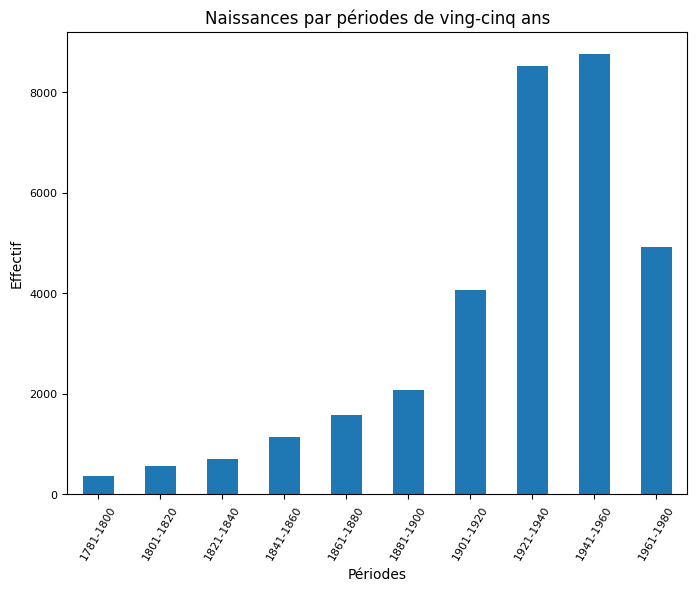

In [37]:
fig, ax = plt.subplots(figsize=(8,6))
ax = cdf_p.groupby(by='periodes').size().plot(kind='bar',rot=60, fontsize=8)
plt.ylabel('Effectif')
plt.xlabel('Périodes')
plt.title('Naissances par périodes de ving-cinq ans')

plt.show()

## Shift to activity date

In [38]:
### Add a new column and enter the result of the function in each row
cdf_p['activityYear'] = cdf_p.apply(lambda x: x['birthYear']+45, axis=1)

In [39]:
cdf_p.head(2)

,s,label,birthYear,genLabel,genCode,periodes,activityYear
0,<http://www.wikidata.org/entity/Q12765268>,Elemír Csere,1917,male,M,1901-1920,1962
1,<http://www.wikidata.org/entity/Q97193482>,Свистунов Володимир Михайлович,1941,male,M,1941-1960,1986


In [40]:
### Créer une liste d'années pour séparer en périodes de 25 ans
# noter que la dernière année sera exclue, 
# elle donc doit être supérieure à la valeur maximale 
l_20 = list(range(1781+45, 2001+45, 20))
print(l_20[:5],l_20[-5:])

[1826, 1846, 1866, 1886, 1906] [1946, 1966, 1986, 2006, 2026]


In [41]:
### fonction pd.cut : https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.cut.html
# On ajoute une nouvelle colonne qui contient la période sur la base de la liste précédente
# et de la valeur de l'année

cdf_p['periodes'] = pd.cut(cdf_p['activityYear'], l_20, right=False)

### Transformer le code ajouté pour qu'il soit plus lisible
# noter qu'on a arrondi les valeurs
cdf_p['periodes'] = cdf_p['periodes'].apply(lambda x : str(int(x.left))+'-'+ str(int(x.right)-1))

# Inspection
cdf_p.head(3)

,s,label,birthYear,genLabel,genCode,periodes,activityYear
0,<http://www.wikidata.org/entity/Q12765268>,Elemír Csere,1917,male,M,1946-1965,1962
1,<http://www.wikidata.org/entity/Q97193482>,Свистунов Володимир Михайлович,1941,male,M,1986-2005,1986
2,<http://www.wikidata.org/entity/Q47453056>,Анатолий Брониславович Ринкевич,1950,male,M,1986-2005,1995


In [42]:
### compter les naissances par périodes de 20 ans
cdf_p.groupby(by='periodes').size()

periodes
1826-1845     370
1846-1865     557
1866-1885     696
1886-1905    1151
1906-1925    1571
1926-1945    2074
1946-1965    4058
1966-1985    8528
1986-2005    8759
2006-2025    4929
dtype: int64

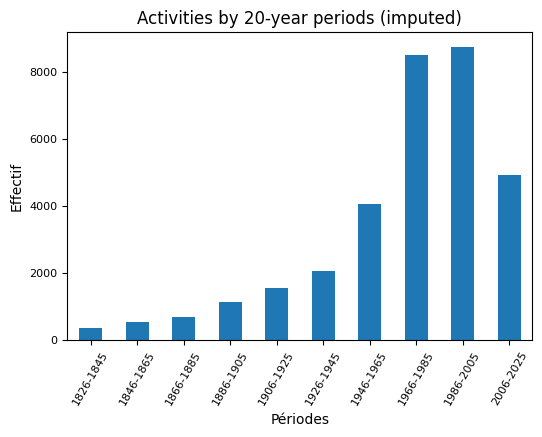

In [43]:
ax = cdf_p.groupby(by='periodes').size().plot(kind='bar',rot=60, fontsize=8, figsize=(6, 4))
plt.ylabel('Effectif')
plt.xlabel('Périodes')
plt.title('Activities by 20-year periods (imputed)')
plt.show()

## Ajouter la représentation des genres

Only female and male, other are omitted because their number is too small for a representation.

They should be inspected separately.



In [44]:
### Regrouper et compter avec un fitre sur le genre masculin
gender_m = pd.DataFrame(cdf_p[cdf_p.genCode == 'M'].groupby('periodes', observed=False).size())
gender_m.columns = ['gen_m']
gender_m.tail()


,gen_m
periodes,
1926-1945,1911
1946-1965,3748
1966-1985,8069
1986-2005,7962
2006-2025,4083


In [45]:
### Regrouper et compter avec un fitre sur le genre féminin
gender_f = pd.DataFrame(cdf_p[cdf_p.genCode == 'F'].groupby('periodes').size())
gender_f.columns = ['gen_f']
gender_f.tail()


,gen_f
periodes,
1926-1945,163
1946-1965,309
1966-1985,458
1986-2005,793
2006-2025,840


In [46]:
### Fusionner les deux tableaux en utilisant l'index comme clé de jointure
merged = pd.merge(gender_m, gender_f, left_index=True, right_index=True)
merged.tail()

,gen_m,gen_f
periodes,,
1926-1945,1911,163
1946-1965,3748,309
1966-1985,8069,458
1986-2005,7962,793
2006-2025,4083,840


In [47]:
### Transformer l'index de séquence à chaîne de caractères
# ce qui est indispensable pour l'affichage dans un graphique
merged.index = merged.index.map(str)
merged.tail()

,gen_m,gen_f
periodes,,
1926-1945,1911,163
1946-1965,3748,309
1966-1985,8069,458
1986-2005,7962,793
2006-2025,4083,840


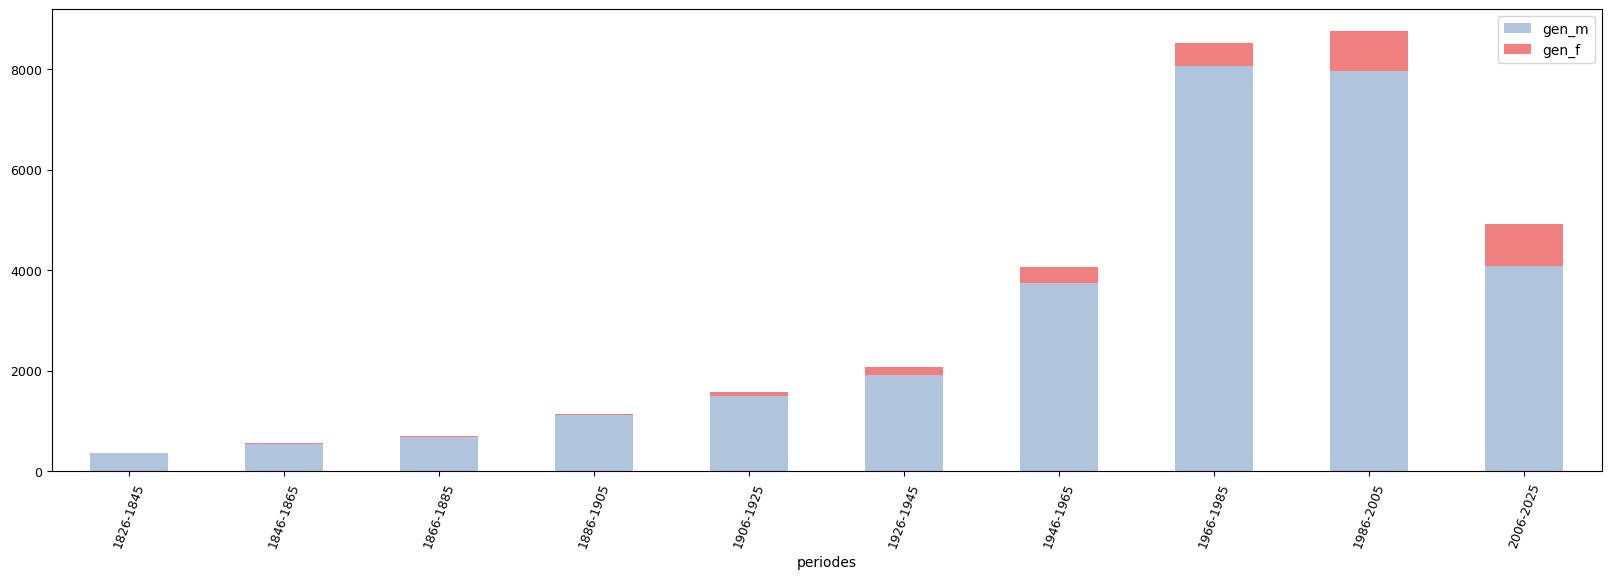

In [48]:
### Documentation
# https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.bar.html
ax = merged.plot.bar(stacked=True, rot=70, fontsize=9, figsize=(20,6), color=['LightSteelBlue', 'LightCoral'])
plt.show()

### Coding of imputed activity dates by ten-year period

Comme on voit bien dans le graphique précédent qu'il y a deux périodes avec des effectifs radicalements différents, 
on restraint la période analysée à l'époque contemporaine et on affine avec un découpage par périodes de dix ans 

In [49]:
l_10 = list(range(1781+45, 1991+45, 10))
print(l_10[:5],l_10[-5:])

[1826, 1836, 1846, 1856, 1866] [1986, 1996, 2006, 2016, 2026]


In [50]:
### Découpage par décennies
## fonction pd.cut : https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.cut.html

cdf_p['per_10'] = pd.cut(cdf_p['activityYear'], l_10, right=False)

### Transformer le code ajouté pour qu'il soit plus lisible
# noter qu'on a arrondi les valeurs
cdf_p['per_10'] = cdf_p['per_10'].apply(lambda x : str(int(x.left))+'-'+ str(int(x.right)-1))

# Inspection
cdf_p.head(3)

,s,label,birthYear,genLabel,genCode,periodes,activityYear,per_10
0,<http://www.wikidata.org/entity/Q12765268>,Elemír Csere,1917,male,M,1946-1965,1962,1956-1965
1,<http://www.wikidata.org/entity/Q97193482>,Свистунов Володимир Михайлович,1941,male,M,1986-2005,1986,1986-1995
2,<http://www.wikidata.org/entity/Q47453056>,Анатолий Брониславович Ринкевич,1950,male,M,1986-2005,1995,1986-1995


In [51]:
### On regroupe par genre comme ci-dessus
gender_m_10 = pd.DataFrame(cdf_p[(cdf_p.genCode == 'M') ].groupby('per_10').size())
gender_m_10.columns = ['gen_m']
gender_m_10.tail()


,gen_m
per_10,
1976-1985,4562
1986-1995,4549
1996-2005,3413
2006-2015,2512
2016-2025,1571


In [52]:
### Idem
gender_f_10 = pd.DataFrame(cdf_p[(cdf_p.genCode == 'F')& (cdf_p.birthYear > 1780)].groupby('per_10').size())
gender_f_10.columns = ['gen_f']
gender_f_10.tail()


,gen_f
per_10,
1976-1985,249
1986-1995,389
1996-2005,404
2006-2015,435
2016-2025,405


In [53]:
merged_10 = pd.merge(gender_m_10, gender_f_10, left_index=True, right_index=True)
merged_10.tail()

,gen_m,gen_f
per_10,,
1976-1985,4562,249
1986-1995,4549,389
1996-2005,3413,404
2006-2015,2512,435
2016-2025,1571,405


In [54]:
### On transforme le type de valeur de l'index
# et on ajoute une colonne avec le total
merged_10.index = merged_10.index.map(str)
merged_10['tot']=merged_10['gen_m']+merged_10['gen_f']
merged_10.tail()

,gen_m,gen_f,tot
per_10,,,
1976-1985,4562,249,4811
1986-1995,4549,389,4938
1996-2005,3413,404,3817
2006-2015,2512,435,2947
2016-2025,1571,405,1976


In [55]:
merged_10.head()

,gen_m,gen_f,tot
per_10,,,
1826-1835,150,0,150
1836-1845,218,2,220
1846-1855,266,2,268
1856-1865,284,5,289
1866-1875,308,4,312


In [56]:
m_10_not_zero = merged_10[merged_10.gen_f > 0]
m_10_not_zero

,gen_m,gen_f,tot
per_10,,,
1836-1845,218,2,220
1846-1855,266,2,268
1856-1865,284,5,289
1866-1875,308,4,312
1876-1885,377,7,384
1886-1895,493,10,503
1896-1905,632,16,648
1906-1915,691,37,728
1916-1925,805,38,843


In [57]:
### On prépare les valeurs pour l'affichage des fréquences (proportion par rapport au total)

# liste qui contient toutes les valeurs à la suite
m_f = m_10_not_zero.gen_m.to_list()+m_10_not_zero.gen_f.to_list()

# liste d'égale longueur que la précédente qui contient 
# les valeurs de l'index, i.e. les périodes
tot = m_10_not_zero.tot.to_list()*2

# liste qui contient les valeurs des fréquences
lp = [round(v/t, 2) for v,t in zip(m_f, tot)]
print(lp[:3])

[0.99, 0.99, 0.98]


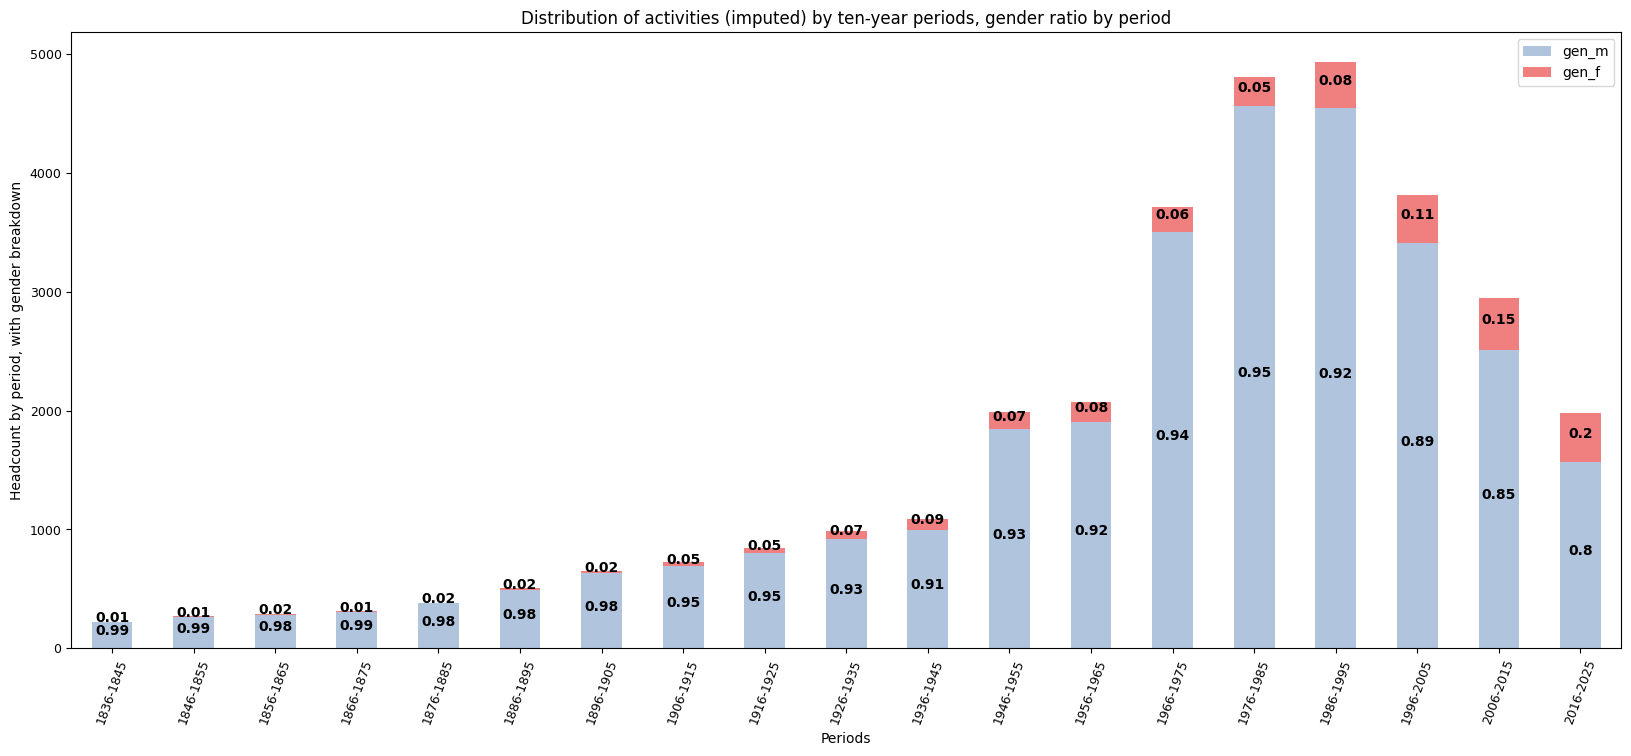

In [60]:
### Graphique avec la distribution par période et genre (M,F)
# Noter que les effectifs du genre 'Autres' étant très faibles,
# on ne les analyse pas de manière sérielle mais on peut les analyser qualitatiement

ax = m_10_not_zero.plot.bar(stacked=True, y=['gen_m', 'gen_f'], \
                        rot=70, fontsize=9, figsize=(20,8), color=['LightSteelBlue', 'LightCoral'])


### https://www.pythoncharts.com/matplotlib/stacked-bar-charts-labels/


## On ajoute une étiquette concernant la valeur de fréquence
# à chaque rectangle dans le graphe, en utilisant la list 'lp' préparée précédemment
# Il y a autant de triangles que les valeurs d'index x le nombre de variables

for bar,v in zip(ax.patches,lp): 

    ax.text(
      # Met les étiquette aux centre des rectangles
      bar.get_x() + bar.get_width() / 2,
        
      # Ajoute les coordonnées verticales
      bar.get_height()/2 + bar.get_y(), 
      
      # Ajoute les valeurs
      v,

      # centre et met du style aux étiquettes
      ha='center',
      color='black',
      weight='bold',
      size=10
  )

plt.ylabel('Headcount by period, with gender breakdown')
plt.xlabel('Periods')
plt.title('Distribution of activities (imputed) by ten-year periods, gender ratio by period')

## On peut enregistrer l'image dans un fichier (noter le dossier créé préalablement)
# qu'on pourra ensuite introduire dans un travail et commenter

# Doc.: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.savefig.html
plt.savefig('images/naissances_distribution_10ans_genre.jpg', bbox_inches='tight',
                       pad_inches=0.2)
plt.show()

### New interactive chart using Plotly 

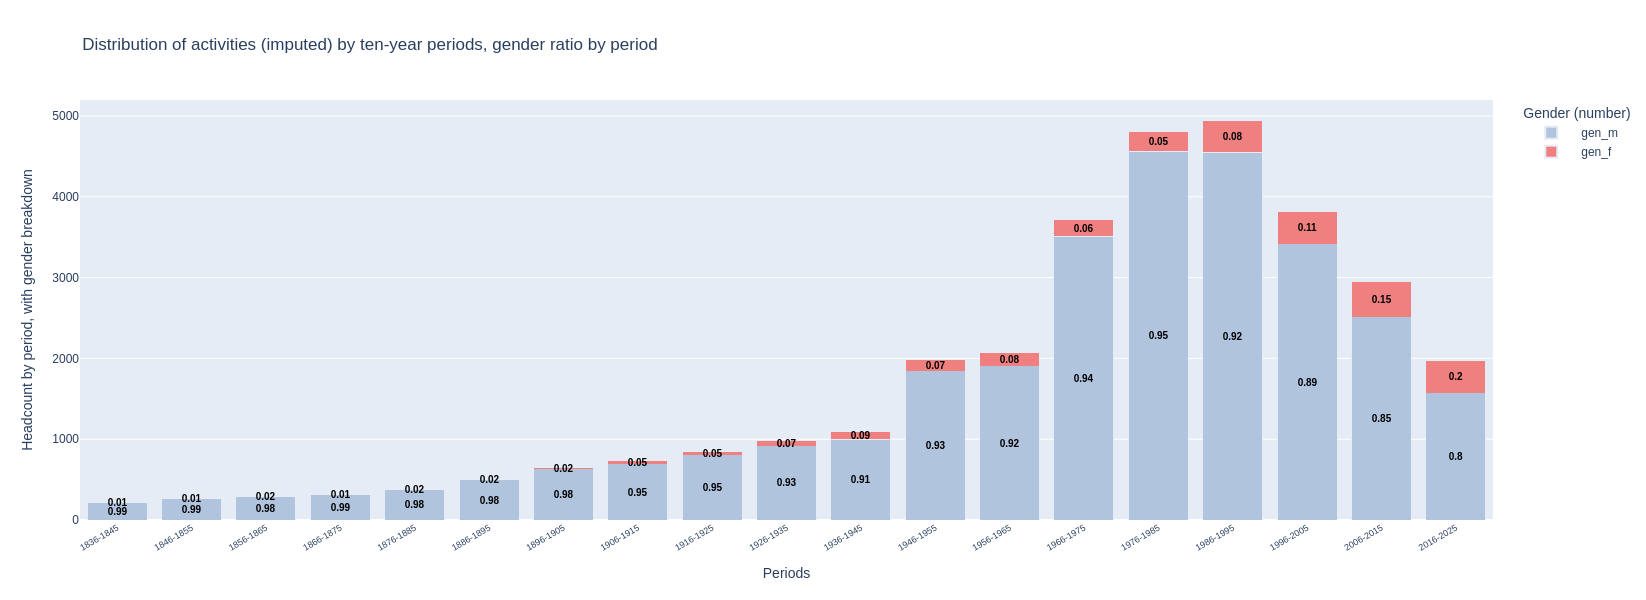

In [71]:
# Reset index to make 'per_10' a column
df_plot = m_10_not_zero.reset_index()

# Calculate percentages per period
df_plot['tot'] = df_plot['gen_m'] + df_plot['gen_f']
df_plot['pct_m'] = df_plot['gen_m'] / df_plot['tot']
df_plot['pct_f'] = df_plot['gen_f'] / df_plot['tot']

# Create stacked bar chart
fig = px.bar(
    df_plot,
    x='per_10',
    y=['gen_m', 'gen_f'],
    color_discrete_map={'gen_m': 'LightSteelBlue', 'gen_f': 'LightCoral'},
    title='Distribution of activities (imputed) by ten-year periods, gender ratio by period',
    labels={'per_10': 'Periods', 'value': 'Number', 'variable': 'Genre'},
    barmode='stack'
)

# Rotate x-axis labels
fig.update_xaxes(tickangle=-30, tickfont=dict(size=9))

# Add percentage labels inside bars
for i, row in df_plot.iterrows():
    # Add gen_m percentage label
    if row['gen_m'] > 0:
        pct_m_str = f"{row['pct_m']:.2f}".rstrip('0').rstrip('.')  
        fig.add_annotation(
            x=row['per_10'],
            y=row['gen_m'] / 2,
            text=pct_m_str,
            showarrow=False,
            font=dict(size=10, color='black', weight='bold'),
            xanchor='center',
            yanchor='middle'
        )
    # Add gen_f percentage label
    if row['gen_f'] > 0:
        pct_f_str = f"{row['pct_f']:.2f}".rstrip('0').rstrip('.')  
        fig.add_annotation(
            x=row['per_10'],
            y=row['gen_m'] + row['gen_f'] / 2,
            text=pct_f_str,
            showarrow=False,
            font=dict(size=10, color='black', weight='bold'),
            xanchor='center',
            yanchor='middle'
        )

# Customize hover info to show actual counts
fig.update_traces(
    hovertemplate='<b>%{x}</b><br>Number %{fullData.name}: %{y}<extra></extra>'
)

# Update layout
fig.update_layout(
    yaxis_title='Headcount by period, with gender breakdown',
    font=dict(size=12),
    width=1000,
    height=600,
    legend_title_text='Gender',
    legend=dict(
        title=dict(text="Gender (number)"),
        itemsizing='constant',
        itemwidth=50
    )
)

# Optional: Customize legend to show counts (e.g., "gen_m (244)")
fig.for_each_trace(lambda t: t.update(name=f"{t.name}") if t.name in ['gen_m', 'gen_f'] else t)   # ({df_plot[t.name].iloc[0]})

# Save as interactive HTML
fig.write_html("interactive_images/naissances_distribution_10ans_genre_percent.html", include_plotlyjs='cdn', full_html=True)

# Optional: Show in notebook or browser
fig.show()
